# Market-basket analysis of The New York Times' articles

Marco Baderna $-$ 3/20/2026

---

## Setup

Downloading the dataset: please
**upload the file `kaggle.json` with the credentials!**

In [1]:
!mkdir ~/.kaggle
!mv kaggle.json ~/.kaggle

In [ ]:
!pip install kaggle

In [2]:
!kaggle datasets download -d benjaminawd/new-york-times-articles-comments-2020

Dataset URL: https://www.kaggle.com/datasets/benjaminawd/new-york-times-articles-comments-2020
License(s): CC-BY-NC-SA-4.0
100% 1.95G/1.95G [00:19<00:00, 108MB/s] 



In [3]:
!unzip /content/new-york-times-articles-comments-2020.zip nyt-articles-2020.csv nyt-comments-2020.csv

Archive:  /content/new-york-times-articles-comments-2020.zip
  inflating: nyt-articles-2020.csv   
  inflating: nyt-comments-2020.csv   


Downloading Spark

In [2]:
#!apt-get update -qq > /dev/null
!apt-get install openjdk-17-jdk-headless -qq > /dev/null # should be already installed
!wget https://dlcdn.apache.org/spark/spark-4.1.1/spark-4.1.1-bin-hadoop3.tgz
!tar xzf spark-4.1.1-bin-hadoop3.tgz
!pip install -q findspark
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64" #TODO
os.environ["SPARK_HOME"] = "/content/spark-4.1.1-bin-hadoop3"
import findspark
findspark.init("spark-4.1.1-bin-hadoop3")# SPARK_HOME
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
sc = spark.sparkContext

--2026-03-20 07:51:49--  https://dlcdn.apache.org/spark/spark-4.1.1/spark-4.1.1-bin-hadoop3.tgz
Resolving dlcdn.apache.org (dlcdn.apache.org)... 151.101.2.132, 2a04:4e42::644
Connecting to dlcdn.apache.org (dlcdn.apache.org)|151.101.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 572739279 (546M) [application/x-gzip]
Saving to: ‘spark-4.1.1-bin-hadoop3.tgz’

spark-4.1.1-bin-had 100%[===================>] 546.21M   100MB/s    in 5.5s    

2026-03-20 07:51:55 (99.8 MB/s) - ‘spark-4.1.1-bin-hadoop3.tgz’ saved [572739279/572739279]



## Building baskets

In [4]:
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import collections
import io
import math
import random
import statistics
import sys

The suggested values of the threshold with respect to the filter selected, in order to keep low the number of frequent pairs.
The filter indicates how many batches read.

Filter  | Threshold
--------|-----------
1       | 370
5       | 600
10      | 650



In [5]:
FILTER = 5
THRESHOLD = 600

In [6]:
def build_baskets(file_path, integer_IDs=True, filter=1):
  '''
  Maps each user to the articles commented.
  The filter argument indicates how many batches read.
  If integer_IDs=true new IDs are assigned to the articles.
  Return the dictionary and a list associating the new IDs with the old ones.
  '''
  userID = io.StringIO()
  articleID = io.StringIO()
  curr_field = 0
  baskets = collections.defaultdict(set)

  comments_read = 0
  BATCH_SIZE = 500_000

  new_ID = {}
  original_IDs = [] # for the caller to recover original articleIDs

  with open(file_path, encoding="utf-8") as file:
    fields = file.readline().split(",")
    for i in range(len(fields)):
      if fields[i] == "userID":
        USER_FIELD = i
      elif fields[i].startswith("articleID"): # may have final \n
        ARTICLE_FIELD = i

    while True:
      c = file.read(1)
      if not c:
        break

      if curr_field == USER_FIELD:
        while True:
          if c == ",":
            curr_field += 1
            break
          else:
            userID.write(c)
          c = file.read(1)

      elif curr_field == ARTICLE_FIELD:
        while True:
          if c == "\n":
            curr_field = 0
            comments_read += 1
            # add entry to dict
            if integer_IDs:
              if articleID.getvalue() not in new_ID:
                id = len(original_IDs)
                original_IDs.append(articleID.getvalue())
                new_ID[articleID.getvalue()] = id
              baskets[userID.getvalue()].add(new_ID[articleID.getvalue()])
            else:
              baskets[userID.getvalue()].add(articleID.getvalue())
            userID.close()
            userID = io.StringIO()
            articleID.close()
            articleID = io.StringIO()
            break
          else:
            articleID.write(c)
          c = file.read(1)
        if comments_read == filter * BATCH_SIZE:
          break

      elif c == '"': # skip all inside apices
        while True:
          c = file.read(1)
          if c == '"':
            break
      elif c == ',':
        curr_field += 1

  print(f'Read {comments_read} comments')
  return (baskets, original_IDs)

build also a small sample to use for the analysis of some algorithms

In [7]:
small_baskets, small_original_IDs = build_baskets("nyt-comments-2020.csv", filter=1)

Read 500000 comments


In [ ]:
start = timer()
baskets, original_IDs = build_baskets("nyt-comments-2020.csv", filter=FILTER)
end = timer()
print(f'Total time: {end-start:.1f}s')

Read 4986461 comments
Total time: 286.6s


In [ ]:
len(original_IDs), len(baskets)

(16787, 403025)

In [ ]:
lenghts = [len(baskets[k]) for k in baskets]
avg, maximum = statistics.mean(lenghts), max(lenghts)
print(f'Avg number of comments: {avg:.2f}\nMax number of comments: {maximum}')

Avg number of comments: 8.88
Max number of comments: 2428


In [ ]:
sorted([(k, len(baskets[k])) for k in baskets], key=lambda i: i[1], reverse=True)[:10]

[('51878992', 2428),
 ('17374907', 2222),
 ('61986282', 2069),
 ('47112177', 1950),
 ('66788641', 1885),
 ('68938663', 1772),
 ('82409470', 1716),
 ('2073520', 1665),
 ('64397379', 1647),
 ('21896305', 1628)]

In [ ]:
print(f'Baskets of size 1: {len([k for k in baskets if len(baskets[k]) == 1])}')
print(f'Baskets of size 2: {len([k for k in baskets if len(baskets[k]) == 2])}')

cleaned = {u: baskets[u] for u in baskets if len(baskets[u]) > 1}

Baskets of size 1: 218323
Baskets of size 2: 52408


18.186911890504703

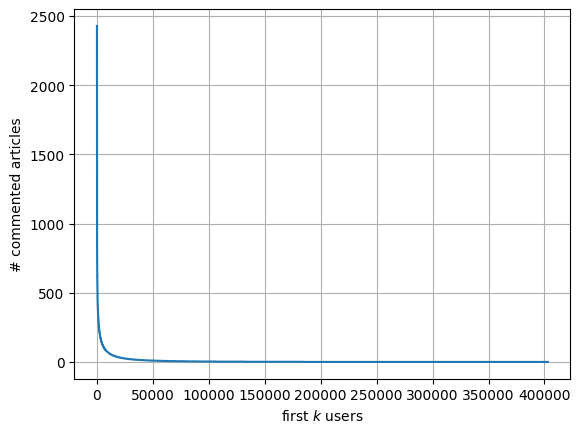

In [ ]:
num_comments = sorted([len(baskets[k]) for k in baskets], reverse=True)
fig, ax = plt.subplots()
ax.plot(range(len(num_comments)), num_comments)
plt.ylabel("# commented articles")
plt.xlabel("first $k$ users")
ax.grid()
plt.show()

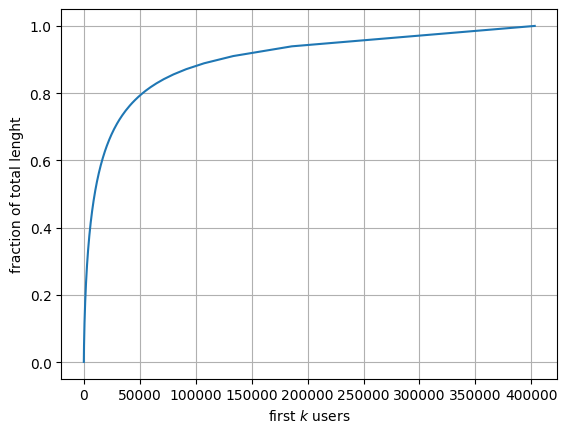

In [ ]:
cum_lens = np.cumsum(num_comments)
cum_lens = cum_lens / cum_lens[-1] # normalize
fig, ax = plt.subplots()
ax.plot(range(len(num_comments)), cum_lens)
plt.ylabel("fraction of total lenght")
plt.xlabel("first $k$ users")
ax.grid()
plt.show()

## Confidence & interest

Define some utility functions to analyze the frequent pairs found by the algorithms

In [ ]:
def confidence_interest(A, b, baskets):
  '''
  Compute confidence and interest of the association rule A -> b
  '''
  supportA = 0
  supportb = 0
  supportAub = 0
  for basket in baskets:
    if A.issubset(basket):
      supportA += 1
    if b.issubset(basket):
      supportb += 1
    if (A | b).issubset(basket):
      supportAub += 1
  confidence = supportAub / supportA
  interest = confidence - (supportb / len(baskets))
  return (confidence, interest)

In [ ]:
def fetch_pair(articles, a1, a2):
  '''
  Select from the articles (pandas dataframe) the ones indicated (by their ID).
  '''
  return articles[(articles.uniqueID == a1) | (articles.uniqueID == a2)][["newsdesk", "section", "subsection", "material", "headline", "abstract", "pub_date", "n_comments"]]

In [ ]:
nyt_articles = pd.read_csv("nyt-articles-2020.csv")
len(nyt_articles)

16787

## A-Priori

In [ ]:
def apriori(baskets, threshold, verbose=True, singletons=False, time=True):
  '''
  Compute frequent pairs of items, according to the thresold in [0,1]
  (i.e. a pair is frequent if the fraction of baskets containing it
  is greater than or equal to the threshold).
  If singletons=True returns also frequent items (as needed by Toivonen).
  '''
  start = timer()
  baskets = list(baskets) # otherwise SON can't do the second pass, since baskets is an iterator

  pairs = [] # result

  # 1° pass
  itemfreq = collections.defaultdict(int)
  for b in baskets:
    for article in b:
      itemfreq[article] += 1

  absth = math.ceil(len(baskets) * threshold)
  if verbose: print(f"A-Priori\n========\nAbsolute threshold: {absth}")

  # 2° pass
  pairfreq = collections.defaultdict(int)
  for b in baskets:
    for a1 in b:
      if itemfreq[a1] >= absth:
        for a2 in b:
          if itemfreq[a2] >= absth and a2 > a1:
            pairfreq[(a1, a2)] += 1
            if pairfreq[(a1, a2)] == absth:
              pairs.append((a1,a2))

  end = timer()
  num_candidatepairs = len(pairfreq) # to check filtering power
  if verbose:
    print(f'Candidate pairs: {num_candidatepairs}\n')
    print(f'Found {len(pairs)} frequent pairs')
    if len(pairs) <= 20:
      for p in pairs:
        print(p, pairfreq[p])
  if time:
    print(f'Total time: {end-start:.1f}s')

  if singletons:
    return (pairs, {i for i in itemfreq if itemfreq[i] >= absth}, num_candidatepairs)
  return pairs

test in on a small example taken from [1]

In [ ]:
test = {
  "A": {"cat", "and", "dog", "bites"},
  "B": {"Yahoo", "news", "claims", "a", "cat", "mated", "with", "dog", "and", "produced", "viable", "offspring"},
  "C": {"cat", "killer", "likely", "is", "a", "big", "dog"},
  "D": {"Professional", "free", "advice", "on", "dog", "training", "puppy"},
  "E": {"cat", "and", "kitten", "training", "and", "behavior"},
  "F": {"dog", "&", "cat", "provides", "dog", "training", "in", "Eugene", "Oregon"},
  "G": {"dog", "and", "cat", "is", "a", "slang", "term", "used", "by", "police", "officers", "for", "relationship"},
  "H": {"Shop", "for", "your", "show", "dog", "grooming", "and", "pet", "supplies"},
}

In [ ]:
r1 = apriori(test.values(), 3/8)

A-Priori
Absolute threshold: 3
Candidate pairs: 9

Found 5 frequent pairs
('cat', 'dog') 5
('and', 'cat') 4
('a', 'dog') 3
('a', 'cat') 3
('and', 'dog') 4
Total time: 0.0s


then run on the NYT articles

In [ ]:
n = len(original_IDs) # number of distinct articles
print(f'Number of possible pairs: {n * (n-1) / 2:.0f}')

Number of possible pairs: 140893291


In [ ]:
r1 = apriori(baskets.values(), THRESHOLD/len(baskets))

A-Priori
Absolute threshold: 650
Candidate pairs: 1193164

Found 4 frequent pairs
(1916, 2068) 710
(1916, 2341) 661
(12379, 12444) 679
(12444, 12581) 650
Total time: 96.9s


### Analysis

In [ ]:
# get titles
for pair in r1:
  articles = fetch_pair(nyt_articles, original_IDs[pair[0]], original_IDs[pair[1]])
  print(articles['headline'].iloc[0], articles['headline'].iloc[1], sep="\n", end="\n\n")

Prosecutors Quit Roger Stone Case After Justice Dept. Intervenes on Sentencing
Barr Says Attacks From Trump Make Work ‘Impossible’

Prosecutors Quit Roger Stone Case After Justice Dept. Intervenes on Sentencing
Lawmakers Are Warned That Russia Is Meddling to Re-elect Trump

Civil Conversation Challenge, Forum 1: How Does Your Identity Inform Your Political Beliefs and Values?
Civil Conversation Challenge for Teenagers, Forum 2: Covid-19 and Our National Response

Civil Conversation Challenge for Teenagers, Forum 2: Covid-19 and Our National Response
Civil Conversation Challenge for Teenagers, Forum 4: Education



In [ ]:
# compute support and interest
for pair in r1:
  c1, i1 = confidence_interest({pair[0]}, {pair[1]}, baskets.values())
  c2, i2 = confidence_interest({pair[1]}, {pair[0]}, baskets.values())

  print(f'{pair[0]} -> {pair[1]}\nConfidence: {c1}\nInterest: {i1}\n{pair[1]} -> {pair[0]}\nConfidence: {c2}\nInterest: {i2}\n')

1916 -> 2068
Confidence: 0.2321019941157241
Interest: 0.22335563843059292
2068 -> 1916
Confidence: 0.20141843971631207
Interest: 0.19382833984657694

1916 -> 2341
Confidence: 0.2160836874795685
Interest: 0.20925036448471707
2341 -> 1916
Confidence: 0.24001452432824982
Interest: 0.2324244244585147

12379 -> 12444
Confidence: 0.3448450990350432
Interest: 0.34095204029178905
12444 -> 12379
Confidence: 0.4327597195666029
Interest: 0.42787416656120625

12444 -> 12581
Confidence: 0.41427660930529
Interest: 0.4111353649656088
12581 -> 12444
Confidence: 0.5134281200631912
Interest: 0.509535061319937



## PCY

In [ ]:

def pcy(baskets, threshold, filter_size=100_000, verbose=True, time=True, memory_footprint=False):
  # filter_size is the len of the array used to build the filter
  start = timer()

  filter = np.zeros(filter_size, dtype=np.uint32)
  pairs = [] # result

  # 1° pass
  itemfreq = collections.defaultdict(int)
  for b in baskets:
    for a1 in b:
      itemfreq[a1] += 1
      for a2 in b:
        if a2 > a1:
          filter[hash((a1,a2)) % filter_size] += 1

  absth = math.ceil(len(baskets) * threshold)

  # free space: turn the filter into a bitmap
  for i in range(len(filter)):
    filter[i] = 1 if filter[i] >= absth else 0
  bitmap = np.packbits(filter, bitorder='little') # array of bytes, made by packing the bits
  # little endian cause read the array from left to right
  if verbose:
    print("PCY\n===")
    print(f'Filter: {sys.getsizeof(filter)} bytes')
    print(f'Bitmap: {sys.getsizeof(bitmap)} bytes')
  del filter

  # 2° pass
  pairfreq = collections.defaultdict(int)
  for b in baskets:
    for a1 in b:
      if itemfreq[a1] >= absth:
        for a2 in b:
          if itemfreq[a2] >= absth and a2 > a1:
            index = hash((a1,a2)) % filter_size
            if (bitmap[index // 8] // 2 ** (index % 8)) % 2 == 1: #extracting the right bit
              pairfreq[(a1, a2)] += 1
              if pairfreq[(a1, a2)] == absth:
                pairs.append((a1,a2))

  end = timer()

  num_candidatepairs = len(pairfreq) # to check filtering power
  if verbose:
    print(f'Candidate pairs: {num_candidatepairs}\n')
    print(f'Found {len(pairs)} frequent pairs')
    if len(pairs) <= 20:
      for p in pairs:
        print(p, pairfreq[p])
  if time:
    print(f'Total time: {end-start:.1f}s')

  if memory_footprint:
    return num_candidatepairs
  else:
    return pairs

In [ ]:
res = pcy(test.values(), 3/8)

PCY
===
Filter: 400112 bytes
Bitmap: 12612 bytes
Candidate pairs: 5

Found 5 frequent pairs
('cat', 'dog') 5
('and', 'cat') 4
('a', 'dog') 3
('a', 'cat') 3
('and', 'dog') 4
Total time: 0.0s


In [ ]:
rp = pcy(baskets.values(), threshold=THRESHOLD/len(baskets), filter_size=1_000_000)

PCY
===
Filter: 4000112 bytes
Bitmap: 125112 bytes
Candidate pairs: 35547

Found 4 frequent pairs
(1916, 2068) 710
(1916, 2341) 661
(12379, 12444) 679
(12444, 12581) 650
Total time: 282.4s


### Analysis
Plot the "filtering power" of PCY, defined as 1 minus the ratio of candidate pairs over possible pairs, as a function of the array lenght. The baseline is the filtering power of A-Priori.

To keep low the running time, I consider the small sample.

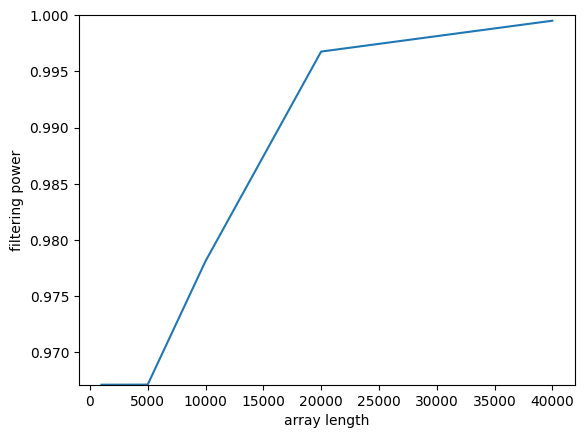

In [ ]:
n = len(small_original_IDs)
possible_pairs = n * (n-1) / 2
sizes = [1_000, 5_000, 10_000, 20_000, 40_000]
threshold = 370
_, _, candidate_pairs_apriori = apriori(small_baskets.values(), threshold/len(small_baskets), singletons=True, verbose=False, time=False)
filter = []
for size in sizes:
  candidate_pairs = pcy(small_baskets.values(), threshold/len(small_baskets), filter_size=size, memory_footprint=True, verbose=False, time=False)
  filter.append(1- candidate_pairs / possible_pairs)

plt.plot(sizes, filter)
plt.ylim(1 - candidate_pairs_apriori / possible_pairs, 1)
plt.xlabel('array length')
plt.ylabel('filtering power')
plt.show()

## SON

In [ ]:
def son(rdd, threshold, num_total_baskets, verbose=True):
  def find_frequent_pairs(baskets): # wrapper cause the map function must have 1 argument
    return [(p,1) for p in apriori(baskets, threshold, verbose=False, time=False)]

  start = timer()
  # 1° job: pairs frequent in the samples
  candidate_pairs = (rdd
                     .mapPartitions(find_frequent_pairs)
                     .reduceByKey(lambda x,y : 1) # removing duplicates
                     .collect()) # list of pairs ((a1,a2), 1)

  # share candidate pairs to all the nodes
  bcast_pairs = sc.broadcast({p for (p,_) in candidate_pairs})

  # 2° job: remove false positives
  frequent_pairs = (rdd
                    .flatMap(lambda b : [((a1,a2),1) for a1 in b for a2 in b if a2>a1 and (a1,a2) in bcast_pairs.value])
                    .reduceByKey(lambda x,y : x+y)
                    .filter(lambda p : p[1] >= math.ceil(threshold*num_total_baskets))
                    .collect()
                    )
  end = timer()
  if verbose:
    print('SON\n===')
    print(f'Found {len(frequent_pairs)} frequent pairs')
    if len(frequent_pairs) <= 20:
      for p in frequent_pairs: print(p)
    print(f'Total time: {end-start:.1f}s')

  return frequent_pairs

testing

In [ ]:
rdd = sc.parallelize(test.values())
rs = son(rdd, 3/8, 8)

SON
===
Found 5 frequent pairs
(('and', 'dog'), 4)
(('a', 'cat'), 3)
(('and', 'cat'), 4)
(('cat', 'dog'), 5)
(('a', 'dog'), 3)
Total time: 7.2s


In [ ]:
rdd = sc.parallelize(baskets.values())#.cache()

In [ ]:
rs = son(rdd, THRESHOLD/len(baskets), len(baskets))

SON
===
Found 4 frequent pairs
((1916, 2068), 710)
((1916, 2341), 661)
((12379, 12444), 679)
((12444, 12581), 650)
Total time: 326.6s


## Toivonen

In [ ]:
def build_sample(baskets, p):
  '''
  Build a sample of the basket file, where each basket is picked with probability p.
  '''
  random.seed()
  sample = []
  for b in baskets:
    if random.random() <= p:
      sample.append(b)
  return sample


In [ ]:
def toivonen(items, baskets, sample_p, threshold, scale_factor, verbose=False, memory_footprint=True, debug=False):
  '''
  Items contains all the possible items.
  sample_p is the probabilty with which add a basket to the sample.
  For the sample the threshold is multiplied by the scale_factor.
  '''
  start = timer()
  sample = build_sample(baskets, sample_p)
  if verbose: print(f'Toivonen\n========\nSample size: {len(sample)}')
  if debug:
    for b in sample:
      print(b)
  sample_pairs, sample_singletons, num_candidate_pairs = apriori(sample,
                                                            threshold*scale_factor, time=False,
                                                            verbose=False, singletons=True)
  if debug:
    print(f'Singletons: {sample_singletons}')
    print(f'Num candidate pairs: {num_candidate_pairs}')
  pairs = {p: 0 for p in sample_pairs} # to compute their actual support

  # build negative border
  nb_s = dict() #
  nb_p = dict() # counters for singletons and pairs in the negative border
  for i in items: # singletons not frequent in the sample
    if i not in sample_singletons:
      nb_s[i] = 0
  for i in sample_singletons: # unfrequent pairs of items frequent in the sample
    for j in sample_singletons:
      if j > i and (i,j) not in pairs:
        nb_p[(i,j)] = 0
  if debug:
    print("Negative border:")
    for e in nb_s:
      print(e)
    for e in nb_p:
      print(e)
    print(f'Elems in negative border: {len(nb_s) + len(nb_p)}')

  # compute actual support
  for b in baskets:
    for i in b:
      if i in nb_s:
        nb_s[i] += 1
      for j in b:
        if j > i and (i,j) in nb_p:
          nb_p[(i,j)] += 1
        elif j > i and (i,j) in pairs:
          pairs[(i,j)] += 1
  if debug:
    print("Support:\n- Negative border")
    for e in nb_s:
      print("{0!s:30} {1!s}".format(e, nb_s[e]))
    for e in nb_p:
      print("{0!s:30} {1!s}".format(e, nb_p[e]))
    print("- Candidate pairs")
    for p in pairs:
      print("{0!s:20} {1!s}".format(p, pairs[p]))
    print(f"Threshold = {threshold*len(baskets)}")
  freq_nb = False
  for k in nb_s:
    if nb_s[k] >= threshold * len(baskets):
      freq_nb = True
  for k in nb_p:
    if nb_p[k] >= threshold * len(baskets):
      freq_nb = True

  res = [] if freq_nb else [k for k in pairs if pairs[k] >= threshold * len(baskets)]

  end = timer()
  if verbose:
    if freq_nb: print("Frequent itemset in the negative border")
    else: print(f'Found {len(res)} frequent pairs')
    if len(res) < 20:
      for p in res:
        print(p, pairs[p])
    print(f'Total time: {end-start:.1f}s')
  if memory_footprint:
    return (res, num_candidate_pairs)
  else :
    return res


testing

In [ ]:
items = set()
for b in test.values():
  for i in b:
    items.add(i)
rt = toivonen(items, test.values(), 0.5, 3/8, 0.4, verbose=True, memory_footprint=False)

Toivonen
Sample size: 3
Frequent itemset in the negative border
Total time: 0.0s


In [ ]:
rt = toivonen(range(len(original_IDs)), baskets.values(), 0.2, THRESHOLD/len(baskets), 0.7, verbose=True, memory_footprint=True)

Toivonen
Sample size: 80799
Found 4 frequent pairs
(1916, 2068) 710
(1916, 2341) 661
(12379, 12444) 679
(12444, 12581) 650
Total time: 266.8s


### Analysis
Plot the average number of candidate pairs considered by A-Priori and the fraction of successful runs of Toivonen as functions of the scaling factor.

To keep low the running time, I consider the small sample.

In [ ]:
ITERATIONS = 10
SAMPLE_P = 0.1
avg_num_pairs = []
success_ratios = []
for k in np.arange(0.1, 1.1, 0.1): # scaling factor
  successful_runs = 0
  num_pairs = 0
  for t in range(ITERATIONS):
    pairs, num_candidate_pairs = toivonen(range(len(small_original_IDs)), small_baskets.values(), SAMPLE_P, 370/len(small_baskets), k, verbose=False, memory_footprint=True)
    num_pairs += num_candidate_pairs
    if len(pairs) > 0:
      successful_runs += 1
  avg_num_pairs.append(num_pairs / ITERATIONS)
  success_ratios.append(successful_runs / ITERATIONS)

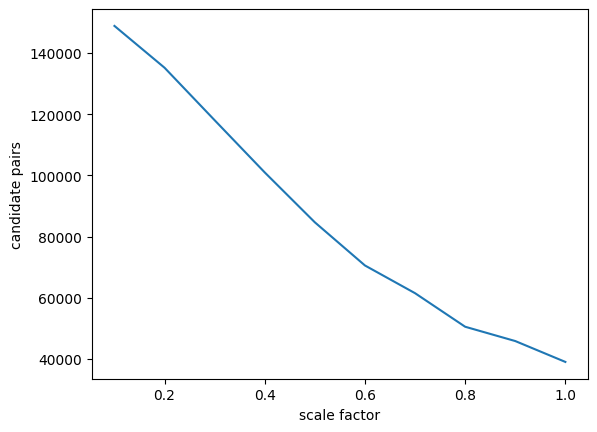

In [ ]:
plt.plot(np.arange(0.1,1.1,0.1), avg_num_pairs)
plt.xlabel("scale factor")
plt.ylabel("candidate pairs")
plt.show()

the space used by the algo decreases, but also the probability of getting a correct result

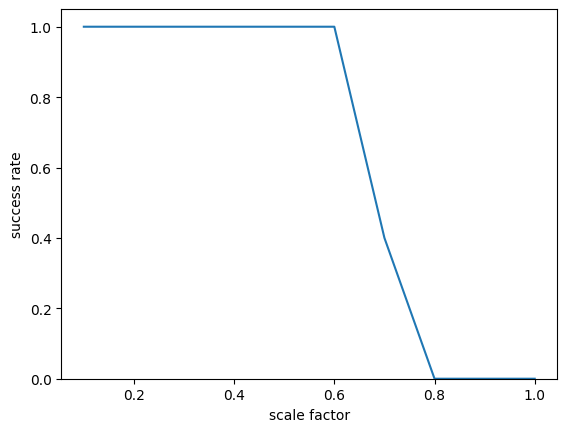

In [ ]:
plt.plot(np.arange(0.1,1.1,0.1), success_ratios)
plt.xlabel("scale factor")
plt.ylabel("success rate")
plt.ylim(0,1.05)
plt.show()

## References

[1] Leskovec, J., Rajaraman, A., & Ullman, J. D. (2014). *Mining of massive datasets*.
Cambridge University press.